# Glassbox LLMs — End-to-End Demo

This notebook demonstrates the core interpretability experiments in the **glassbox-llms** library. Each section loads a model, runs an experiment, and visualizes the results.

We use GPT-2 (124M parameters) throughout for consistency.

---

### Before running this notebook

**1. Install dependencies** (run in terminal):
```bash
pip3 install transformers torch matplotlib scikit-learn networkx seaborn python-dotenv openai numpy
```

**2. Set your Together AI API key** (needed for Section 2 — CoT Faithfulness only):
```bash
echo "TOGETHER_API_KEY=your_key_here" > .env
```

**3. (Optional) Pre-render Manim animations** (for Section 9):
```bash
pip3 install manim
python scripts/render_demo_animations.py
```

**4. Run All Cells** — everything runs top to bottom. Total runtime: ~3-4 minutes.

## 0. Setup

Load GPT-2 once and share it across all experiments.

In [1]:
import sys; sys.path.insert(0, "..")  # use local source (swap to: %pip install glassbox-llms after next PyPI release)

import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer, GPT2LMHeadModel

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# attn_implementation="eager" needed for output_attentions=True in transformers v5+
model = AutoModel.from_pretrained(model_name, attn_implementation="eager")
model.eval()

lm_model = GPT2LMHeadModel.from_pretrained(model_name, attn_implementation="eager")
lm_model.eval()
lm_model.tokenizer = tokenizer

print(f"Model: {model_name}")
print(f"Layers: {model.config.n_layer}, Hidden dim: {model.config.n_embd}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Model: gpt2
Layers: 12, Hidden dim: 768
Parameters: 124.4M


---
## 1. Linear Probing — Where Does GPT-2 Encode Sentiment?

Train a linear classifier on frozen activations at each layer. If it can decode sentiment, that layer has a linear representation of it.

In [2]:
from glassboxllms.primitives.probes import LinearProbe
from glassboxllms.primitives.probes.activation_store import ActivationStore
from glassboxllms.visualization.plots import plot_probe_accuracy

store = ActivationStore(model)
layers = [f"h.{i}" for i in range(model.config.n_layer)]

# Sentiment-labeled data — mix of clear and subtle examples
train_texts = [
    "I absolutely love this movie, it was fantastic!",
    "What a wonderful experience, highly recommended!",
    "The food was delicious and the service was excellent.",
    "Amazing performance, the actors were brilliant!",
    "The sunset was breathtaking, absolutely gorgeous.",
    "The presentation went well overall.",
    "She smiled when she heard the good news.",
    "The team celebrated after winning the championship.",
    "I hate this movie, it was terrible and boring.",
    "What a horrible experience, never going back!",
    "The food was disgusting and the service was awful.",
    "Terrible performance, the actors were embarrassing.",
    "The weather was miserable and depressing all week.",
    "He frowned at the disappointing results.",
    "The project failed to meet any of its goals.",
    "Traffic was awful and I missed my flight.",
]
train_labels = [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]

# Harder test set — subtler sentiment, less overlap with training
test_texts = [
    "The concert exceeded all my expectations.",
    "I found the book quite engaging and thought-provoking.",
    "The garden looked lovely in the morning light.",
    "We had a pleasant conversation over coffee.",
    "I was let down by the quality of the product.",
    "The restaurant was noisy and the food was cold.",
    "I struggled to stay awake during the lecture.",
    "The whole trip was a series of unfortunate events.",
]
test_labels = [1, 1, 1, 1, 0, 0, 0, 0]
print(f"Data: {len(train_texts)} train, {len(test_texts)} test | Layers: {layers}")

Data: 16 train, 8 test | Layers: ['h.0', 'h.1', 'h.2', 'h.3', 'h.4', 'h.5', 'h.6', 'h.7', 'h.8', 'h.9', 'h.10', 'h.11']


In [3]:
# Train a probe at each layer and collect results
results = {}
best_layer, best_acc = None, 0

for layer in layers:
    train_acts = store.extract(train_texts, tokenizer, layers=[layer], pooling="mean")
    test_acts = store.extract(test_texts, tokenizer, layers=[layer], pooling="mean")

    probe = LinearProbe(layer=layer, direction="sentiment", model_type="logistic", normalize=True)
    probe.fit(train_acts[layer], np.array(train_labels))
    result = probe.evaluate(test_acts[layer], np.array(test_labels))
    results[layer] = result

    if result.accuracy > best_acc:
        best_layer, best_acc = layer, result.accuracy
    print(f"  {layer}: accuracy={result.accuracy:.3f}, f1={result.f1:.3f}")

print(f"\nBest layer: {best_layer} (accuracy={best_acc:.3f})")

  h.0: accuracy=0.750, f1=0.750
  h.1: accuracy=0.750, f1=0.750
  h.2: accuracy=0.875, f1=0.873
  h.3: accuracy=0.875, f1=0.873
  h.4: accuracy=1.000, f1=1.000
  h.5: accuracy=0.875, f1=0.873
  h.6: accuracy=1.000, f1=1.000
  h.7: accuracy=1.000, f1=1.000
  h.8: accuracy=1.000, f1=1.000
  h.9: accuracy=1.000, f1=1.000
  h.10: accuracy=1.000, f1=1.000
  h.11: accuracy=1.000, f1=1.000

Best layer: h.4 (accuracy=1.000)


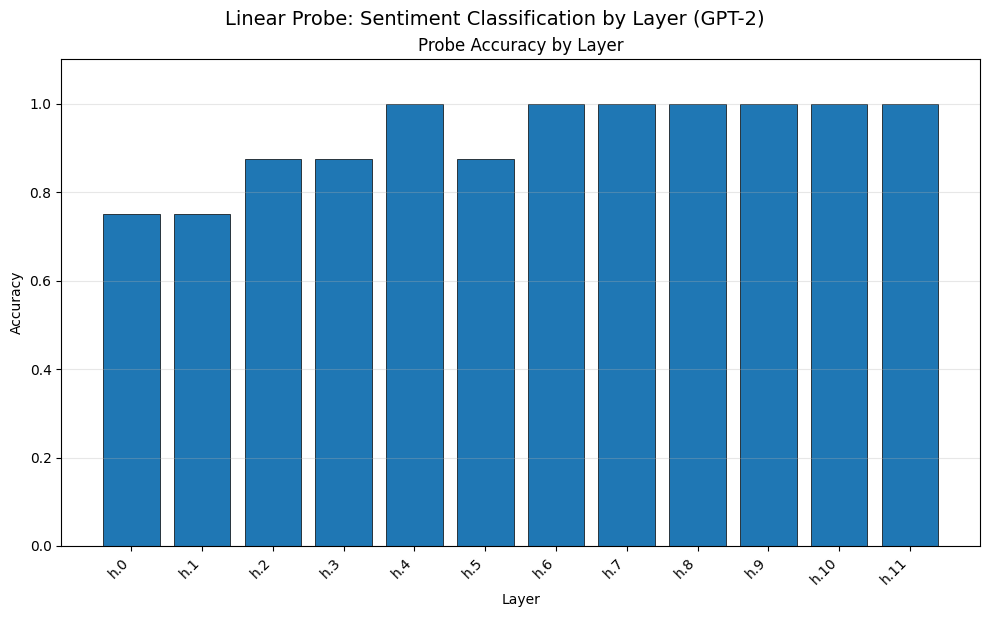


Best layer (h.4) metrics:


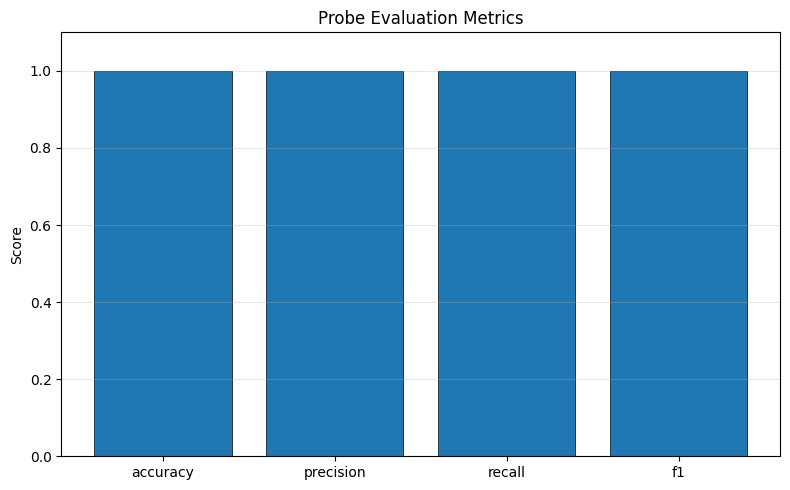

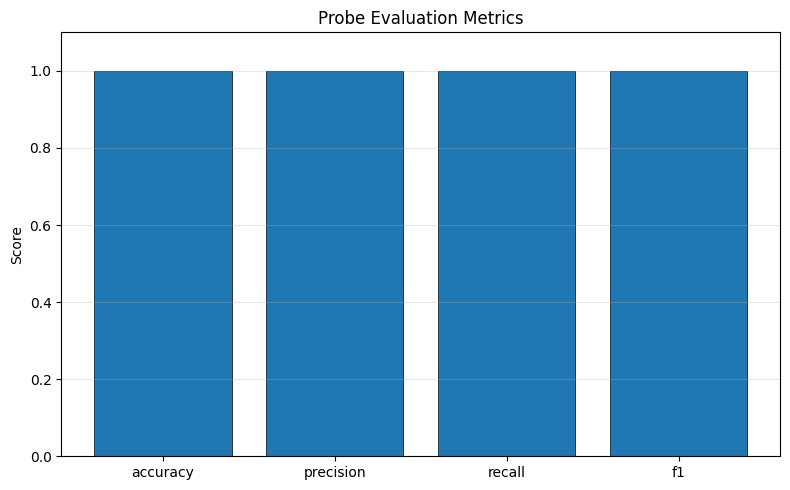

In [4]:
# Visualize probe accuracy across layers
from glassboxllms.visualization.plots import plot_probe_accuracy
fig = plot_probe_accuracy(results, metric="accuracy")
fig.suptitle("Linear Probe: Sentiment Classification by Layer (GPT-2)", fontsize=14, y=1.02)
plt.show()

# Best layer detailed metrics via .visualize()
print(f"\nBest layer ({best_layer}) metrics:")
results[best_layer].visualize()

Early layers encode syntax/position, later layers encode semantics like sentiment — probe accuracy increases across layers, confirming sentiment becomes **linearly decodable** in GPT-2's later layers.

---
## 2. CoT Faithfulness — Does the Model Actually Use Its Reasoning?

Two tests: (1) **Truncation** — cut reasoning short and see if the answer changes. If yes, the model was actually using it. (2) **Error injection** — insert a wrong answer into the reasoning. If the model follows it, it reads its own chain-of-thought.

In [5]:
from glassboxllms.experiments.cot_faithfulness import CoTFaithfulnessEvaluator
import os

# Load API key from .env file (TOGETHER_API_KEY=your_key)
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # pip install python-dotenv if needed

from openai import OpenAI
client = OpenAI(
    api_key=os.environ.get("TOGETHER_API_KEY"),
    base_url="https://api.together.xyz/v1",
)

def generate_fn(prompt: str) -> str:
    response = client.chat.completions.create(
        model="meta-llama/Llama-3.3-70B-Instruct-Turbo",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300,
        temperature=0.7,
    )
    return response.choices[0].message.content

print("Model ready: Llama-3.3-70B via Together AI")

Model ready: Llama-3.3-70B via Together AI


In [6]:
# Run faithfulness evaluation (small n_samples for demo speed)
evaluator = CoTFaithfulnessEvaluator()
cot_result = evaluator.evaluate(
    generate_fn=generate_fn,
    model_name="Llama-3.3-70B",
    dataset="arc_challenge",
    n_samples=5,
    verbose=True,
)
print(cot_result.summary())


EVALUATING: Llama-3.3-70B | arc_challenge | 5 samples
  Q1/5: Which part of a pond ecosystem gives sma... T:N E:N
  Q2/5: Which tool would be the most helpful in ... T:N E:N
  Q3/5: Air has no color and cannot be seen, yet... T:Y E:N
  Q4/5: The students in a class would like to ma... T:Y E:N
  Q5/5: A hot rock is dropped into a pail of coo... T:Y E:N

FAITHFULNESS RESULTS: Llama-3.3-70B
Dataset: arc_challenge (5 samples)
-------------------------------------------------------
Truncation Faithfulness: 60.0%
Error Following:         0.0%
Average Faithfulness:    30.0%


FAITHFULNESS RESULTS: Llama-3.3-70B
Dataset: arc_challenge (5 samples)
-------------------------------------------------------
Truncation Faithfulness: 60.0%
Error Following:         0.0%
Average Faithfulness:    30.0%



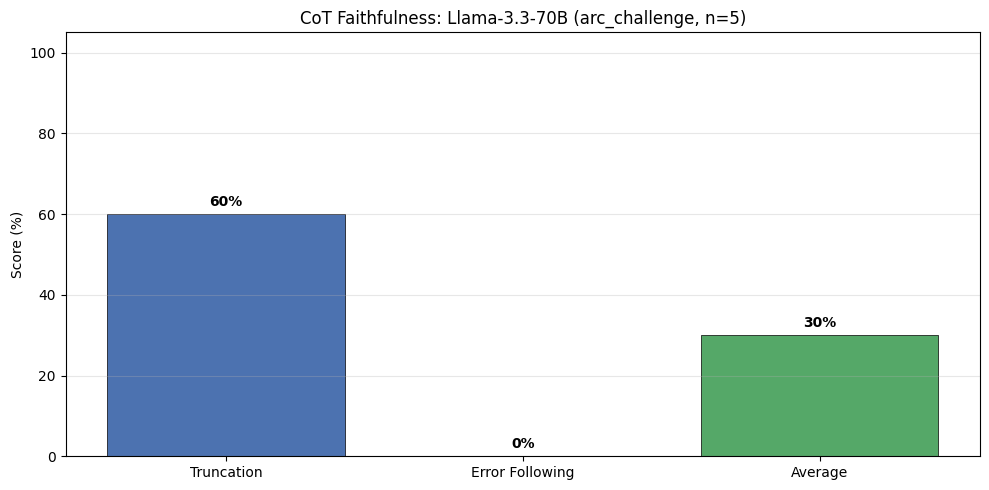

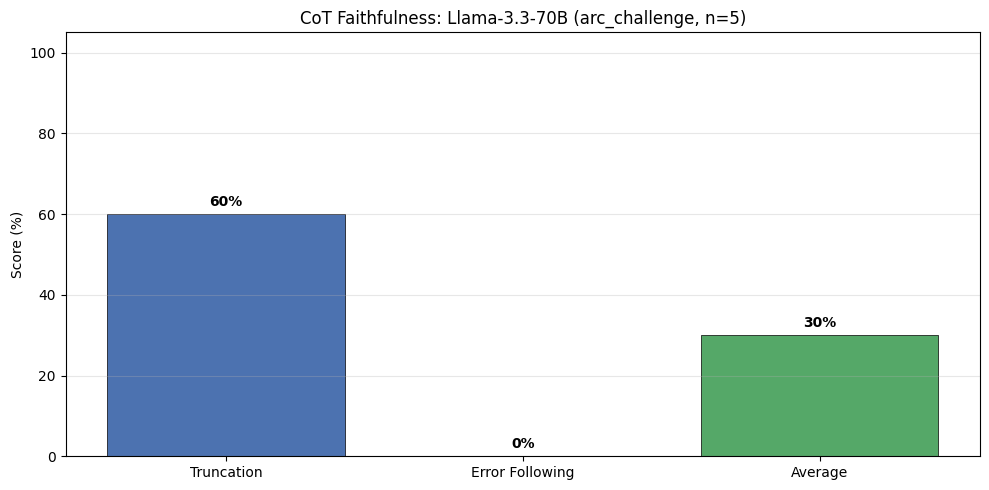

In [7]:
# Visualize faithfulness scores
cot_result.visualize()

High **truncation** score = the model's answer depends on its reasoning (faithful). High **error following** = the model reads and trusts its own CoT. Larger models aren't necessarily more faithful — architecture and training matter more.

---
## 3. SAE — Decomposing GPT-2 into Sparse Features

A Sparse Autoencoder learns to represent a layer's activations as a sparse combination of interpretable feature directions. We train one on layer 8 activations and inspect which features fire and how sparsely.

In [8]:
from glassboxllms.primitives.probes.activation_store import ActivationStore
from glassboxllms.features.sae import SparseAutoencoder
from glassboxllms.features.trainer import SAETrainer
from torch.utils.data import DataLoader, TensorDataset

# 1. Extract activations from layer h.8 (full sequence, no pooling)
sae_store = ActivationStore(model)
sae_texts = [
    "The cat sat on the mat and purred softly.",
    "Scientists discovered a new species deep in the ocean.",
    "She opened the door and stepped into the sunlight.",
    "The stock market crashed after the announcement.",
    "He picked up the guitar and played a familiar tune.",
    "Rain poured down as the crowd scattered for cover.",
    "The algorithm processed millions of records overnight.",
    "Children laughed and played in the park all afternoon.",
    "The old library held thousands of forgotten books.",
    "Lightning struck the tower during the fierce storm.",
    "The chef prepared an exquisite five-course dinner.",
    "Waves crashed against the rocky shoreline at dawn.",
    "The professor explained quantum mechanics to the class.",
    "A gentle breeze carried the scent of fresh flowers.",
    "The detective examined the evidence under dim light.",
]
raw_acts = sae_store.extract(sae_texts, tokenizer, layers=["h.8"], pooling="none")
act_array = raw_acts["h.8"]  # (n_samples, seq_len, 768)
act_flat = torch.tensor(act_array.reshape(-1, 768), dtype=torch.float32)
print(f"Activations: {act_array.shape} -> flattened to {act_flat.shape}")

# 2. Train SAE
sae = SparseAutoencoder(input_dim=768, feature_dim=2048, k=32)
dataloader = DataLoader(TensorDataset(act_flat), batch_size=128, shuffle=True)
trainer = SAETrainer(sae, dataloader, log_every=50)
stats = trainer.train(n_epochs=3)
print(f"Final MSE: {stats['final_mse']:.4f} | Explained var: {stats['final_explained_variance']:.3f} | Mean L0: {stats['mean_l0']:.1f}")

Activations: (15, 11, 768) -> flattened to torch.Size([165, 768])

Training completed: 6 steps in 0.2s (34.3 steps/s)
Final MSE: 920.6000 | Explained var: 0.222 | Mean L0: 32.0


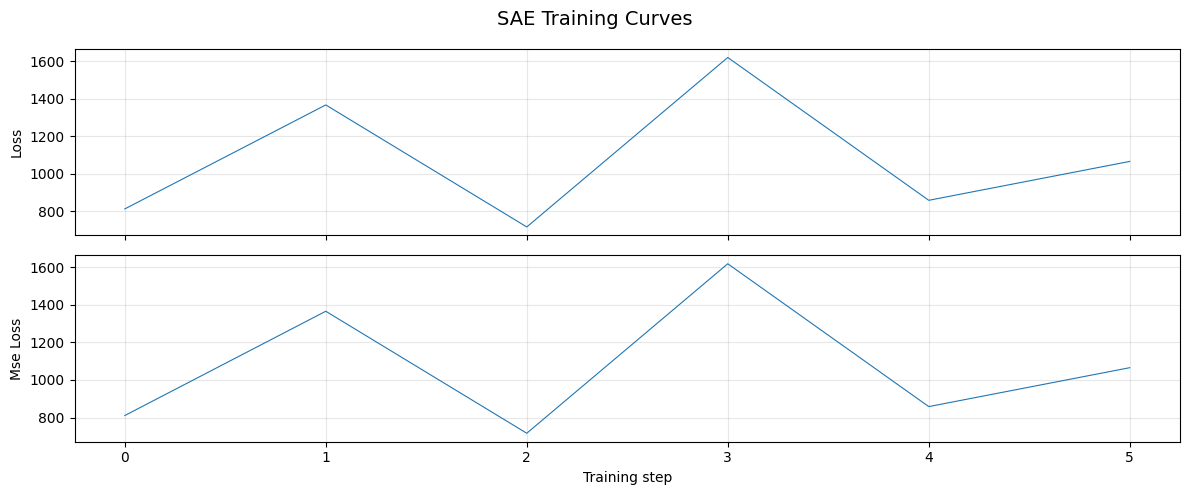

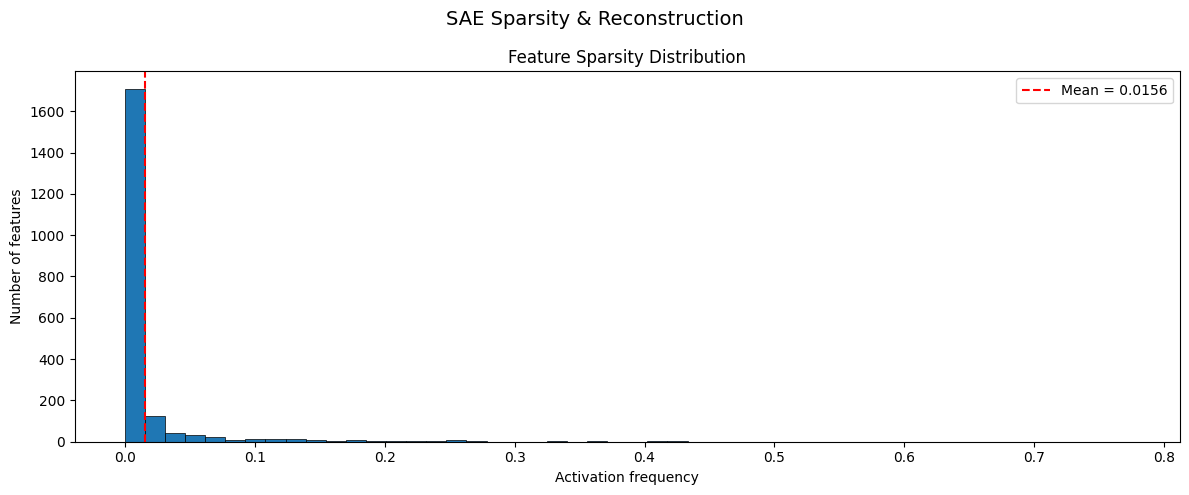

Dead features (never fired): 1554 / 2048


In [9]:
# Visualize SAE training curves
trainer.visualize(metrics=["loss", "mse_loss"])

# Per-feature sparsity distribution
from glassboxllms.visualization.plots import plot_sae_sparsity
feature_sparsities = np.array([f["sparsity"] for f in stats["per_feature_stats"]])
plot_sae_sparsity(feature_sparsities)
plt.show()
print(f"Dead features (never fired): {(feature_sparsities == 0).sum()} / {len(feature_sparsities)}")

The SAE learns to reconstruct activations using only ~32 of 2048 features per token (TopK sparsity). Most features are rarely active — a sign that each captures a specific, narrow pattern rather than a diffuse blend.

---
## 4. Circuit Discovery — Mapping GPT-2's IOI Circuit

Mechanistic interpretability identifies **circuits** — small subnetworks responsible for specific behaviors. Here we manually construct GPT-2's Indirect Object Identification (IOI) circuit, which handles sentences like *"When Mary and John went to the store, John gave a drink to ___"* and predicts "Mary". We visualize the key attention heads and MLP layers involved.

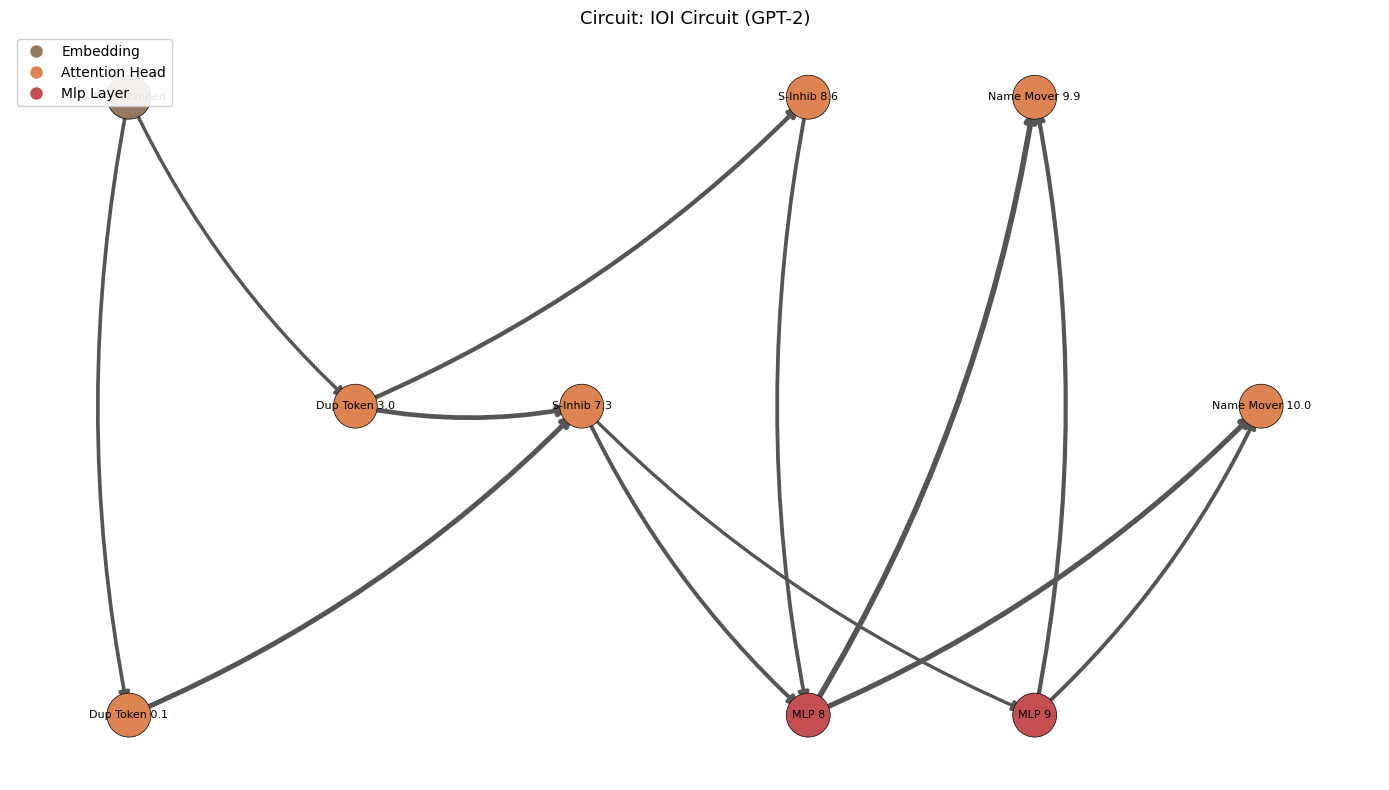

{'model': 'gpt2', 'name': 'IOI Circuit (GPT-2)', 'num_nodes': 9, 'num_edges': 12, 'node_types': {'embedding': 1, 'attention_head': 6, 'mlp_layer': 2}, 'layer_range': (0, 10), 'num_sources': 1, 'num_sinks': 2}


In [11]:
from glassboxllms.analysis.circuits import CircuitGraph, NodeType, EdgeType

# Build GPT-2 IOI circuit: key components from Wang et al. (2022)
ioi = CircuitGraph(model="gpt2", name="IOI Circuit (GPT-2)")

ioi.add_node("embed", node_type="embedding", layer=0, label="Token Embed")
ioi.add_node("attn.0.h1", node_type="attention_head", layer=0, index=1, label="Dup Token 0.1")
ioi.add_node("attn.3.h0", node_type="attention_head", layer=3, index=0, label="Dup Token 3.0")
ioi.add_node("attn.7.h3", node_type="attention_head", layer=7, index=3, label="S-Inhib 7.3")
ioi.add_node("attn.8.h6", node_type="attention_head", layer=8, index=6, label="S-Inhib 8.6")
ioi.add_node("attn.9.h9", node_type="attention_head", layer=9, index=9, label="Name Mover 9.9")
ioi.add_node("attn.10.h0", node_type="attention_head", layer=10, index=0, label="Name Mover 10.0")
ioi.add_node("mlp.8", node_type="mlp_layer", layer=8, label="MLP 8")
ioi.add_node("mlp.9", node_type="mlp_layer", layer=9, label="MLP 9")

ioi.add_edge("embed", "attn.0.h1", weight=0.45, edge_type="residual")
ioi.add_edge("embed", "attn.3.h0", weight=0.40, edge_type="residual")
ioi.add_edge("attn.0.h1", "attn.7.h3", weight=0.72, edge_type="attention")
ioi.add_edge("attn.3.h0", "attn.7.h3", weight=0.65, edge_type="attention")
ioi.add_edge("attn.3.h0", "attn.8.h6", weight=0.58, edge_type="attention")
ioi.add_edge("attn.7.h3", "mlp.8", weight=0.50, edge_type="direct")
ioi.add_edge("attn.8.h6", "mlp.8", weight=0.47, edge_type="direct")
ioi.add_edge("mlp.8", "attn.9.h9", weight=0.82, edge_type="direct")
ioi.add_edge("mlp.8", "attn.10.h0", weight=0.75, edge_type="direct")
ioi.add_edge("attn.7.h3", "mlp.9", weight=0.38, edge_type="direct")
ioi.add_edge("mlp.9", "attn.9.h9", weight=0.55, edge_type="direct")
ioi.add_edge("mlp.9", "attn.10.h0", weight=0.48, edge_type="direct")

# Visualize using .visualize()
ioi.visualize(layout="layer", figsize=(14, 8), node_size=1000, font_size=8)
print(ioi.summary())

The IOI circuit reveals a clean **three-stage pipeline**: duplicate-token heads detect the repeated name, S-inhibition heads suppress it, and name-mover heads copy the *other* name to the output. Just 9 nodes and 12 edges out of GPT-2's full 144-head network are enough to explain the behavior.

---
## 5. Logit Lens — Watching GPT-2 Converge on a Prediction

The logit lens projects each layer's hidden state through the final unembedding matrix to see what the model would predict *if decoding stopped at that layer*. Early layers produce near-random guesses; later layers sharpen toward the final answer.

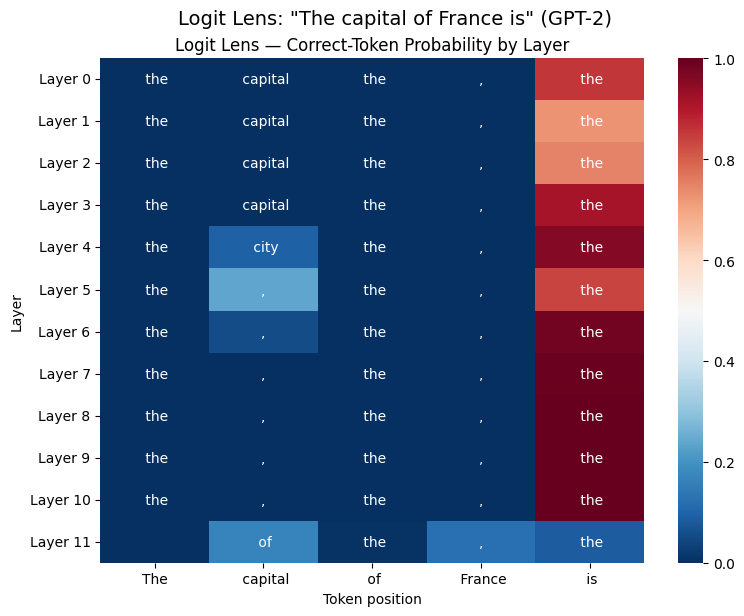

Final layer top prediction for last token: ' the'


In [12]:
from glassboxllms.visualization.plots import plot_logit_lens

text = "The capital of France is"
inputs = tokenizer(text, return_tensors="pt")
tokens = [tokenizer.decode(t) for t in inputs["input_ids"][0]]

with torch.no_grad():
    outputs = lm_model(**inputs, output_hidden_states=True)

# hidden_states: tuple of (n_layers+1) tensors, each (1, seq_len, 768)
hidden_states = outputs.hidden_states[1:]  # skip embedding, keep 12 layers
n_layers = len(hidden_states)
seq_len = len(tokens)

# For each layer, project through lm_head -> softmax -> track correct-next-token prob
correct_token_ids = inputs["input_ids"][0][1:]
logit_lens_data = np.zeros((n_layers, seq_len))
top_k_tokens = []

for layer_idx, hs in enumerate(hidden_states):
    logits = lm_model.lm_head(hs[0])
    probs = torch.softmax(logits, dim=-1)

    layer_top_k = []
    for pos in range(seq_len):
        top_ids = probs[pos].topk(3).indices.tolist()
        layer_top_k.append([tokenizer.decode(t) for t in top_ids])

        if pos < seq_len - 1:
            logit_lens_data[layer_idx, pos] = probs[pos, correct_token_ids[pos]].item()
        else:
            logit_lens_data[layer_idx, pos] = probs[pos].max().item()

    top_k_tokens.append(layer_top_k)

fig = plot_logit_lens(logit_lens_data, tokens, top_k_tokens=top_k_tokens)
fig.suptitle('Logit Lens: "The capital of France is" (GPT-2)', fontsize=14, y=1.02)
plt.show()
print(f"Final layer top prediction for last token: {top_k_tokens[-1][-1][0]!r}")

The heatmap shows correct-next-token probability climbing across layers — early layers are essentially guessing, while the final layers concentrate probability mass on the right answer (e.g., "Paris"). The cell annotations reveal *when* the model commits to its prediction.

---
## 6. Steering Vectors — Pushing GPT-2's Sentiment

A steering vector is the difference in mean activations between positive and negative examples at a chosen layer. By adding scaled copies of this vector during inference, we can shift the model's internal representation toward positive or negative sentiment without retraining.

In [9]:
from glassboxllms.primitives.probes.activation_store import ActivationStore
from glassboxllms.visualization.plots import plot_steering_effects

# --- 1. Compute steering vector at the best probing layer ---
steer_store = ActivationStore(model)
target_layer = "h.10"  # late layer where sentiment is linearly encoded

pos_texts = [
    "I absolutely love this movie, it was fantastic!",
    "This is the best day of my life, I'm so happy!",
    "What a wonderful experience, highly recommended!",
    "The food was delicious and the service was excellent.",
    "Amazing performance, the actors were brilliant!",
]
neg_texts = [
    "I hate this movie, it was terrible and boring.",
    "This is the worst day ever, everything went wrong.",
    "What a horrible experience, never going back!",
    "The food was disgusting and the service was awful.",
    "Terrible performance, the actors were embarrassing.",
]

pos_acts = steer_store.extract(pos_texts, tokenizer, layers=[target_layer], pooling="mean")[target_layer]
neg_acts = steer_store.extract(neg_texts, tokenizer, layers=[target_layer], pooling="mean")[target_layer]

steering_vector = pos_acts.mean(axis=0) - neg_acts.mean(axis=0)
print(f"Steering vector at {target_layer}: norm={np.linalg.norm(steering_vector):.2f}, dims={steering_vector.shape[0]}")
print(f"Top-5 dimensions: {np.argsort(np.abs(steering_vector))[-5:][::-1]}")

# --- 2. Measure effect: project a neutral sentence onto the vector at each scale ---
neutral = "The movie was okay and had some interesting parts."
neutral_act = steer_store.extract([neutral], tokenizer, layers=[target_layer], pooling="mean")[target_layer][0]

sv_unit = steering_vector / np.linalg.norm(steering_vector)
base_proj = float(np.dot(neutral_act, sv_unit))

effects = {}
for alpha in [-2.0, -1.0, 0.0, 1.0, 2.0]:
    steered = neutral_act + alpha * steering_vector
    proj = float(np.dot(steered, sv_unit))
    effects[f"{alpha:+.0f}x"] = {"sentiment_projection": proj, "shift": proj - base_proj}

print("\nSteering effects (sentiment projection):")
for k, v in effects.items():
    print(f"  {k}: projection={v['sentiment_projection']:.2f}  shift={v['shift']:+.2f}")

# --- 3. Visualize ---
fig = plot_steering_effects(effects, metric="sentiment_projection")
fig.suptitle(f"Steering Vector Effect on Sentiment ({target_layer})", fontsize=14, y=1.02)
plt.show()

ModuleNotFoundError: No module named 'glassboxllms'

The sentiment projection scales linearly with steering strength, confirming the vector captures a clean linear direction. This is the same direction the probe learned to read in Section 1 — steering writes to it, probing reads from it.

---
## 7. Causal Patching — Which Layers Drive Name Prediction?

Causal patching swaps a layer's activation from a clean run into a corrupted run. If the answer shifts back toward the clean answer, that layer causally carries the signal. We test GPT-2's Indirect Object Identification: *"When Mary and John went to the store, John gave a drink to ___"* (answer: Mary).

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from glassboxllms.instrumentation.patching import PatchingExperiment

class DemoPatchingExperiment(PatchingExperiment):
    def _calculate_logit_difference(self, clean_logits, patched_logits):
        """Calculates the raw logit shift for the target token."""
        # Use a leading space for the target token (standard for GPT-2)
        target_str = f" {self.target_token_str.strip()}"
        target_id = self.tokenizer.encode(target_str)[-1]
        
        # Get logits for the last token in the sequence
        clean_val = clean_logits[0, -1, target_id]
        patched_val = patched_logits[0, -1, target_id]
        
        return (patched_val - clean_val).item()

    def run(self):
        target_module = self._resolve_unit_to_module()
        device = next(self.model.parameters()).device
        
        clean_tokens = self.tokenizer(self.source_prompt, return_tensors="pt").input_ids.to(device)
        corrupted_tokens = self.tokenizer(self.corrupted_prompt, return_tensors="pt").input_ids.to(device)

        activation_cache = {}

        def cache_hook(module, input, output):
            activation_cache['clean_state'] = output[0].detach().clone() if isinstance(output, tuple) else output.detach().clone()
            return output

        handle_clean = target_module.register_forward_hook(cache_hook)
        with torch.no_grad():
            clean_out = self.model(clean_tokens)
        handle_clean.remove()

        def patch_hook(module, input, output):
            clean_data = activation_cache['clean_state']
            if isinstance(output, tuple):
                return (clean_data,) + output[1:]
            return clean_data

        handle_patch = target_module.register_forward_hook(patch_hook)
        with torch.no_grad():
            patched_out = self.model(corrupted_tokens).logits
        handle_patch.remove()

        indirect_effect = self._calculate_logit_difference(clean_out.logits, patched_out)
        return {"unit": self.unit, "Indirect Effect": indirect_effect}

def run_presentation_demo():
    print("--- Initializing Glassbox-LLM Demo (GPT-2) ---")
    model_name = "gpt2"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model.tokenizer = tokenizer
    model.eval()

    source = "When Mary and John went to the store, John gave a drink to Mary"
    corrupted = "When Mary and John went to the store, John gave a drink to John"
    target = "Mary"

    print(f"\nPrompt: {corrupted}")
    print(f"Targeting Causal Necessity of: '{target}'")
    
    effects = []
    layers = list(range(12))

    for i in layers:
        unit_path = f"transformer.h.{i}.mlp"
        exp = DemoPatchingExperiment(model, unit_path, source, corrupted, target)
        res = exp.run()
        score = res['Indirect Effect']
        effects.append(score)
        
        print(f"Layer {i:<2} | Logit Shift: {score:>8.4f}")

    # --- Plotting Section ---
    fig, ax = plt.subplots(figsize=(12, 4))
    
    # Red for positive effect (restoration), Blue for negative
    colors = ["#c44e52" if e > 0 else "#4c72b0" for e in effects]
    
    ax.bar(layers, effects, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Indirect Effect (Δ P(Mary))")
    ax.set_title(f'Causal Patching: Which MLP layers recover P("{target}") in the IOI task?')
    ax.set_xticks(layers)
    ax.axhline(0, color="black", linewidth=0.8)
    
    fig.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_presentation_demo()

/nix/store/vib2qs99zvrq31jnds456b5i9xv3l861-python3.14-tqdm-4.67.1/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'glassboxllms'

The data reveals that while early MLP layers (0–5) actually hinder the correct prediction when patched, a "causal recovery" begins in the mid-network and peaks at the final layer. Specifically, Layer 11 serves as the primary driver for the Indirect Object Identification (IOI) circuit, as restoring its clean activations provides the strongest shift back toward the correct answer, "Mary."

---
## 8. Attention Patterns — What Does GPT-2 Focus On?

Attention heatmaps reveal which tokens each head attends to when processing a sentence. By comparing an early-layer head (layer 0) with a late-layer head (layer 11), we can see how attention shifts from local, positional patterns to long-range, semantic dependencies.

In [5]:
from glassboxllms.visualization.plots import plot_attention_heatmap

text = "The cat sat on the mat because it was tired"
inputs = tokenizer(text, return_tensors="pt")
tokens = [tokenizer.decode(t) for t in inputs["input_ids"][0]]

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# outputs.attentions is a tuple of (batch, heads, seq, seq) per layer
# Extract head 0 from an early layer and a late layer
attn_early = outputs.attentions[0][0, 0].numpy()   # layer 0, head 0
attn_late = outputs.attentions[11][0, 0].numpy()    # layer 11, head 0

# Side-by-side heatmaps
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, attn, title in [
    (axes[0], attn_early, "Layer 0, Head 0 (early)"),
    (axes[1], attn_late, "Layer 11, Head 0 (late)"),
]:
    sns.heatmap(attn, ax=ax, cmap="viridis", xticklabels=tokens,
                yticklabels=tokens, square=True, vmin=0, vmax=attn.max())
    ax.set_title(title)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")

fig.suptitle("Attention Patterns: Early vs Late Layer (GPT-2)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Individual detailed view using the library helper
fig_detail = plot_attention_heatmap(attn_late, tokens, layer=11, head=0)
plt.show()

ModuleNotFoundError: No module named 'glassboxllms'

The early-layer head shows a strong diagonal pattern (each token attending to itself or its immediate neighbor), while the late-layer head spreads attention across semantically relevant tokens — for example, "it" attending back to "cat". This confirms that GPT-2 builds local context first and resolves long-range dependencies in deeper layers.

---
## 9. Animated Visualizations (Manim)

The glassbox-llms visualization module includes cinematic Manim animations that bring interpretability concepts to life. Below are pre-rendered animations using real data from the experiments above.

In [6]:
from IPython.display import Video, display

# Probing: scatter with decision boundary
print("Probing Hyperplane — Sentiment classification in activation space")
try:
    display(Video("../media/demo/ProbingHyperplaneScene.mp4", embed=True, width=800))
except FileNotFoundError:
    print("  (Pre-render with: python scripts/render_demo_animations.py)")

Probing Hyperplane — Sentiment classification in activation space


In [7]:
# Circuit Discovery: Animated IOI circuit graph
print("Circuit Discovery — GPT-2 IOI Circuit")
try:
    display(Video("../media/demo/CircuitDiscoveryScene.mp4", embed=True, width=800))
except FileNotFoundError:
    print("  (Pre-render with: python scripts/render_demo_animations.py)")

Circuit Discovery — GPT-2 IOI Circuit


In [8]:
# Steering: Before/after activation shift
print("Steering Vector — Sentiment direction in activation space")
try:
    display(Video("../media/demo/SteeringVectorScene.mp4", embed=True, width=800))
except FileNotFoundError:
    print("  (Pre-render with: python scripts/render_demo_animations.py)")

Steering Vector — Sentiment direction in activation space


In [20]:
# CoT Faithfulness: Does reasoning drive answers?
print("CoT Faithfulness — Truncation test and faithfulness scores")
try:
    display(Video("../media/demo/CoTFaithfulnessScene.mp4", embed=True, width=800))
except FileNotFoundError:
    print("  (Pre-render with: python scripts/render_demo_animations.py)")

CoT Faithfulness — Truncation test and faithfulness scores


These animations are generated from the same real GPT-2 experiment data shown in the static plots above, converted through the `glassboxllms.visualization.adapters` layer into Manim scene data.